# PROJECT 4 SUPER SALES ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [3]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/Sample - Superstore.csv")  # adjust to your exact filename

p = DATA_PATH
if not p.exists():
    # Try common Superstore names/extensions
    for alt in [
        "../data/Sample - Superstore.xls",
        "../data/Sample - Superstore.xlsx",
        "../data/Sample-Superstore.xls",
        "../data/Sample-Superstore.xlsx",
        "../data/Sample-Superstore.csv",
    ]:
        q = Path(alt)
        if q.exists():
            p = q
            break

print("Using file:", p)

if p.suffix.lower() in [".xls", ".xlsx"]:
    df = pd.read_excel(p)
else:
    # Try the usual encodings
    for enc in ["utf-8", "utf-8-sig", "cp1252", "latin-1"]:
        try:
            df = pd.read_csv(p, encoding=enc)
            print(f"Loaded with encoding: {enc}")
            break
        except UnicodeDecodeError:
            continue


Using file: ..\data\Sample - Superstore.csv
Loaded with encoding: cp1252


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## Compact helpers (missing, dtypes, quick look)

In [5]:
def missing_report(df, top=20):
    miss = df.isna().sum().sort_values(ascending=False)
    pct = (miss / len(df)).round(4) * 100
    out = pd.DataFrame({"missing": miss, "%": pct})
    return out[out["missing"] > 0].head(top)

def dtypes_overview(df):
    return df.dtypes.to_frame("dtype")

def peek(df, n=3):
    display(df.sample(n, random_state=42))


In [6]:
peek(df, 5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3125,3126,CA-2015-121720,6/11/2015,6/12/2015,First Class,JE-15610,Jim Epp,Corporate,United States,Lakeland,Florida,33801,South,OFF-ST-10003816,Office Supplies,Storage,Fellowes High-Stak Drawer Files,563.81,4,0.20,21.14
1441,1442,CA-2017-128160,12/19/2017,12/24/2017,Second Class,MM-17920,Michael Moore,Consumer,United States,San Francisco,California,94110,West,OFF-BI-10001510,Office Supplies,Binders,Deluxe Heavy-Duty Vinyl Round Ring Binder,36.67,2,0.20,11.46
4510,4511,CA-2016-119935,11/10/2016,11/14/2016,Standard Class,KM-16225,Kalyca Meade,Corporate,United States,Springfield,Missouri,65807,Central,FUR-FU-10001085,Furniture,Furnishings,3M Polarizing Light Filter Sleeves,37.30,2,0.00,17.16
39,40,CA-2015-117415,12/27/2015,12/31/2015,Standard Class,SN-20710,Steve Nguyen,Home Office,United States,Houston,Texas,77041,Central,FUR-CH-10004218,Furniture,Chairs,"Global Fabric Manager's Chair, Dark Gray",212.06,3,0.30,-15.15
4509,4510,CA-2017-167003,5/23/2017,5/29/2017,Standard Class,VS-21820,Vivek Sundaresam,Consumer,United States,Los Angeles,California,90036,West,FUR-TA-10001520,Furniture,Tables,"Lesro Sheffield Collection Coffee Table, End T...",171.29,3,0.20,-6.42


In [7]:
missing_report(df)

,missing,%


In [8]:
dtypes_overview(df)

,dtype
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


## Standardize column names (clean, snake_case)

In [9]:
def to_snake(s: str) -> str:
    return (
        s.strip()
         .replace("/", " ")
         .replace("-", " ")
         .replace("%", "pct")
         .replace("&", "and")
    )

df.columns = (
    df.columns
      .map(to_snake)
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)


In [10]:
df.columns.tolist()

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit']

##  Trim strings and normalize whitespace

In [11]:
obj_cols = df.select_dtypes(include="object").columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()

## Convert dates and basic integrity checks

In [12]:
# Convert typical date columns if present
for c in ["order_date", "ship_date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Sanity: ship_date should be on/after order_date
if set(["order_date","ship_date"]).issubset(df.columns):
    bad_ship = (df["ship_date"] < df["order_date"]).sum()
    print("Rows with ship_date < order_date:", bad_ship)

Rows with ship_date < order_date: 0


## Coerce numeric columns

In [13]:
for c in ["sales", "profit", "discount", "quantity"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Optional: cap obviously wrong discounts (e.g., > 1 treated as 0–1 rate)
if "discount" in df.columns:
    too_big = (df["discount"] > 1).sum()
    if too_big:
        print("Discount values > 1 found:", too_big, "→ converting to 0–1 scale if ≤ 100")
        df.loc[(df["discount"] > 1) & (df["discount"] <= 100), "discount"] = df["discount"] / 100


## Duplicates

In [14]:
print("Exact duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().copy()

# Optional: if there is an order ID + row-level key, dedupe on that:
for key in [["row_id"], ["order_id","product_id"], ["order_id","product_name"]]:
    if all(k in df.columns for k in key):
        before = len(df)
        df = df.drop_duplicates(subset=key).copy()
        print(f"Deduped by {key}: {before - len(df)} rows removed")
        break


Exact duplicate rows: 0
Deduped by ['row_id']: 0 rows removed


## Handle missing values (pragmatic defaults)

In [15]:
# View missing again
missing_report(df)

# Numeric NA → 0 where it makes sense
for c in ["sales", "profit", "discount", "quantity"]:
    if c in df.columns and df[c].isna().any():
        fill_val = 0 if c in ["profit","discount","quantity"] else df[c].median()
        df[c] = df[c].fillna(fill_val)

# Dates: drop rows with missing order_date (critical)
if "order_date" in df.columns:
    before = len(df)
    df = df.dropna(subset=["order_date"]).copy()
    print("Dropped rows with NA order_date:", before - len(df))

# Text: fill NA with "Unknown" for key categoricals
for c in ["category", "sub_category", "segment", "region", "state", "city"]:
    if c in df.columns and df[c].isna().any():
        df[c] = df[c].fillna("Unknown")


Dropped rows with NA order_date: 0


## Create helpful time features & KPIs

In [16]:
# Time features
if "order_date" in df.columns:
    df["order_year"]  = df["order_date"].dt.year
    df["order_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

# KPIs
if set(["sales","profit"]).issubset(df.columns):
    df["margin_pct"] = np.where(df["sales"] != 0, df["profit"] / df["sales"], np.nan)

# Optional: revenue after discount if price columns exist; otherwise keep standard KPIs.
df[["sales","profit","margin_pct"]].describe().T


,count,mean,std,min,25%,50%,75%,max
sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"
margin_pct,"9,994.00",0.12,0.47,-2.75,0.07,0.27,0.36,0.50


## Validation

In [17]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
display(missing_report(df))
display(df.describe(include="number").T.head(10))
display(df.head(3))


Rows: 9994
Columns: 24


,missing,%


,count,mean,std,min,25%,50%,75%,max
row_id,"9,994.00","4,997.50","2,885.16",1.00,"2,499.25","4,997.50","7,495.75","9,994.00"
postal_code,"9,994.00","55,190.38","32,063.69","1,040.00","23,223.00","56,430.50","90,008.00","99,301.00"
sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48"
quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00
discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98"
order_year,"9,994.00","2,015.72",1.12,"2,014.00","2,015.00","2,016.00","2,017.00","2,017.00"
margin_pct,"9,994.00",0.12,0.47,-2.75,0.07,0.27,0.36,0.50


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,order_year,order_month,margin_pct
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,2016-11-01,0.16
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,2016-11-01,0.30
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,2016-06-01,0.47


## KPI Calculation

### Total Sales, Profit, Margin %, Orders, Average Discount.

In [18]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
avg_discount = df["discount"].mean()
margin_pct = total_profit / total_sales

In [19]:
print(f"Total Sales: ${total_sales:,.0f}")
print(f"Total Profit: ${total_profit:,.0f}")
print(f"Profit Margin: {margin_pct:.2%}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Discount: {avg_discount:.2%}")

Total Sales: $2,297,201
Total Profit: $286,397
Profit Margin: 12.47%
Total Orders: 5,009
Average Discount: 15.62%


In [20]:
# ---Breakdown tables ---
kpi_category = (
    df.groupby("category")[["sales","profit"]]
      .sum()
      .sort_values("sales", ascending=False)
)
kpi_category["margin_pct"] = (kpi_category["profit"] / kpi_category["sales"]) * 100
print("Sales & Profit by Category:")
display(kpi_category)

kpi_segment = (
    df.groupby("segment")[["sales","profit"]]
      .sum()
      .sort_values("sales", ascending=False)
)
kpi_segment["margin_pct"] = (kpi_segment["profit"] / kpi_segment["sales"]) * 100
print("Sales & Profit by Segment:")
display(kpi_segment)

kpi_region = (
    df.groupby("region")[["sales","profit"]]
      .sum()
      .sort_values("sales", ascending=False)
)
kpi_region["margin_pct"] = (kpi_region["profit"] / kpi_region["sales"]) * 100
print("Sales & Profit by Region:")
display(kpi_region)


Sales & Profit by Category:


,sales,profit,margin_pct
category,,,
Technology,"836,154.03","145,454.95",17.40
Furniture,"741,999.80","18,451.27",2.49
Office Supplies,"719,047.03","122,490.80",17.04


Sales & Profit by Segment:


,sales,profit,margin_pct
segment,,,
Consumer,"1,161,401.34","134,119.21",11.55
Corporate,"706,146.37","91,979.13",13.03
Home Office,"429,653.15","60,298.68",14.03


Sales & Profit by Region:


,sales,profit,margin_pct
region,,,
West,"725,457.82","108,418.45",14.94
East,"678,781.24","91,522.78",13.48
Central,"501,239.89","39,706.36",7.92
South,"391,721.91","46,749.43",11.93


## Visualizations

### Plotly version

pip install -U kaleido


In [26]:
import os

# Create the folder if it doesn't exist
os.makedirs("../plots", exist_ok=True)


In [28]:
import os
os.getcwd()

'C:\\Users\\venzo\\sales_analysis\\notebooks'

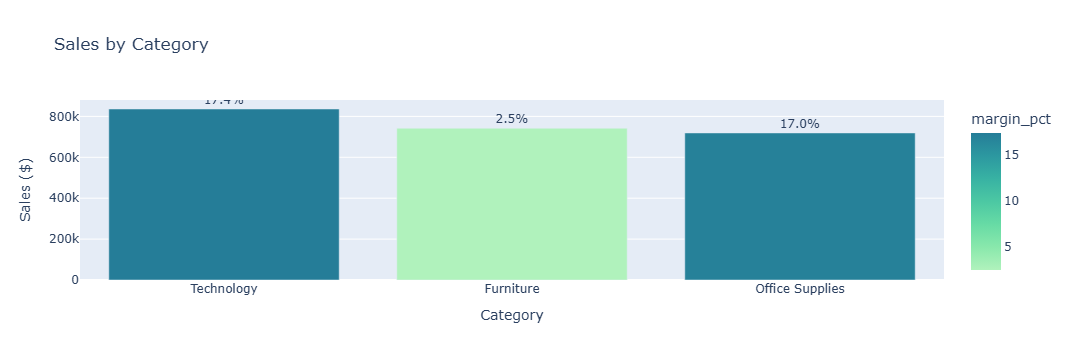

In [29]:
cat_sales = (
    df.groupby("category", as_index=False)
      .agg({"sales":"sum", "profit":"sum"})
      .sort_values("sales", ascending=False)
)
cat_sales["margin_pct"] = (cat_sales["profit"] / cat_sales["sales"]) * 100

fig = px.bar(
    cat_sales,
    x="category", y="sales",
    color="margin_pct",
    text=cat_sales["margin_pct"].round(1).astype(str) + "%",
    title="Sales by Category",
    color_continuous_scale="Tealgrn"
)
fig.update_layout(xaxis_title="Category", yaxis_title="Sales ($)")
fig.update_traces(textposition="outside")
fig.show()
fig.write_image("../plots/sales_by_category_plotly.png", scale=3)

### Seaborn version

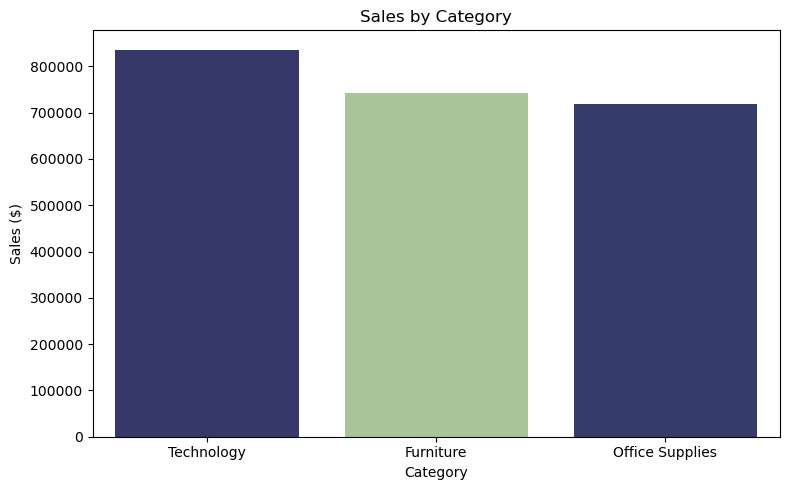

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(data=cat_sales, x="category", y="sales", hue="margin_pct", palette="crest")
plt.title("Sales by Category")
plt.ylabel("Sales ($)")
plt.xlabel("Category")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig("../plots/sales_by_category_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()

## Sales by Region

### Plotly version

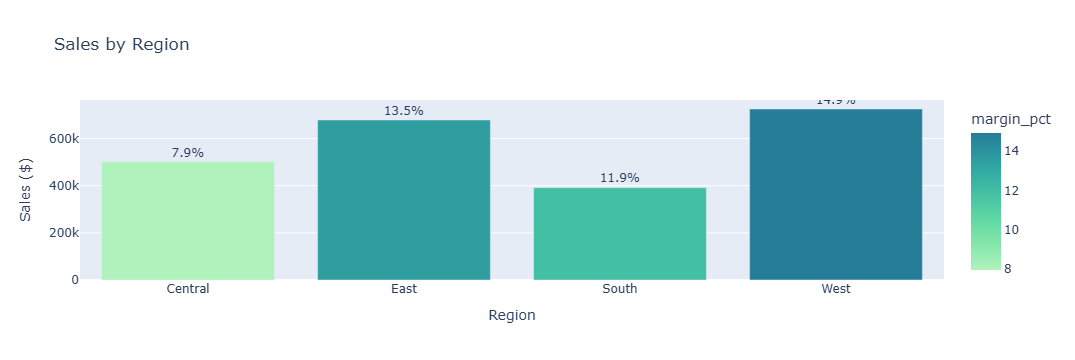

In [31]:
region_sales = df.groupby("region", as_index=False)[["sales","profit"]].sum()
region_sales["margin_pct"] = (region_sales["profit"] / region_sales["sales"]) * 100

fig = px.bar(
    region_sales, x="region", y="sales", color="margin_pct",
    text=region_sales["margin_pct"].round(1).astype(str) + "%",
    title="Sales by Region",
    color_continuous_scale="Tealgrn"
)
fig.update_layout(xaxis_title="Region", yaxis_title="Sales ($)")
fig.update_traces(textposition="outside")
fig.write_image("../plots/sales_by_region_plotly.png", scale=3)
fig.show()


### Seaborn version

C:\Users\venzo\AppData\Local\Temp\ipykernel_14020\2518036806.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




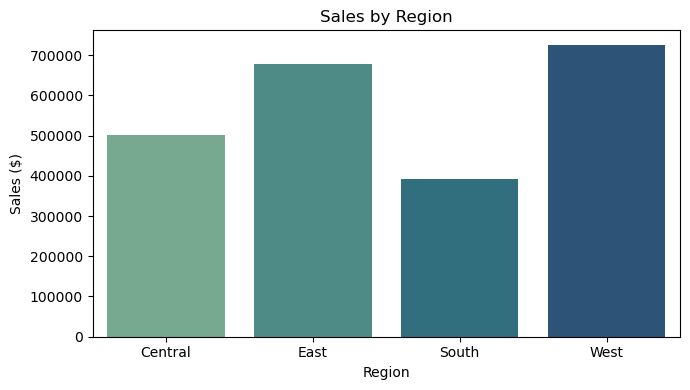

In [32]:
plt.figure(figsize=(7,4))
sns.barplot(data=region_sales, x="region", y="sales", palette="crest")
plt.title("Sales by Region")
plt.ylabel("Sales ($)")
plt.xlabel("Region")
plt.tight_layout()
plt.savefig("../plots/sales_by_region_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()

## Monthly Sales Trend

### Plotly version

C:\Users\venzo\AppData\Local\Temp\ipykernel_14020\2845344817.py:3: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



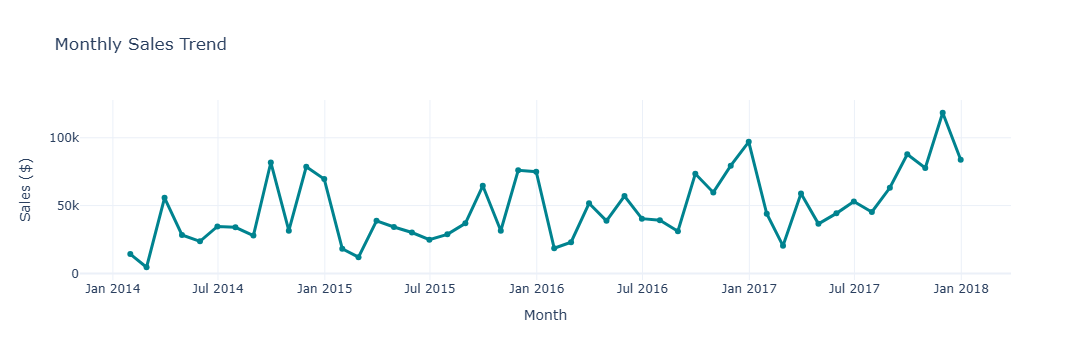

In [33]:
monthly_sales = (
    df.set_index("order_date")
      .resample("M")[["sales","profit"]]
      .sum()
      .reset_index()
)

fig = px.line(
    monthly_sales,
    x="order_date",
    y="sales",
    title="Monthly Sales Trend",
    markers=True,
)
fig.update_traces(line=dict(color="#00838F", width=3))  # un teal moderno
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Sales ($)",
    template="plotly_white"
)
fig.write_image("../plots/monthly_sales_trend_plotly.png", scale=3)
fig.show()

### Seaborn version

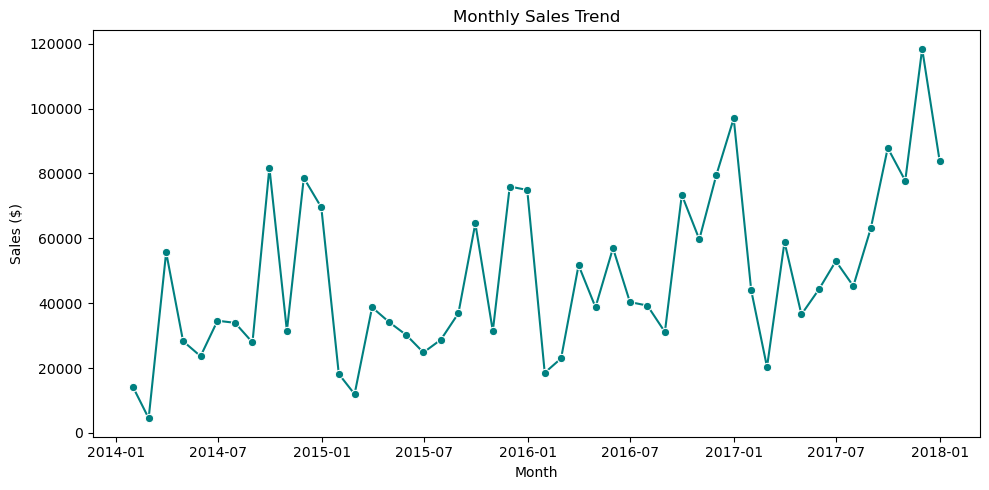

In [34]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x="order_date", y="sales", color="teal", marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales ($)")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("../plots/monthly_sales_trend_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()


## Profit vs. Discount (Correlation)

### Plotly version

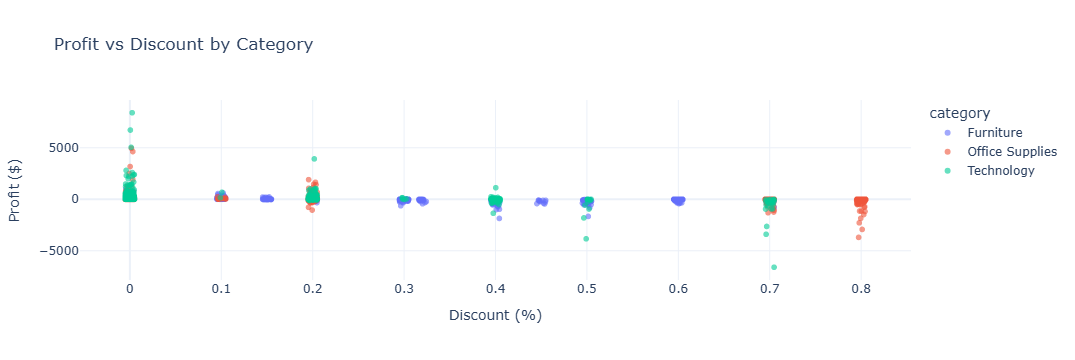

In [35]:
df["discount_jitter"] = df["discount"] + np.random.uniform(-0.005, 0.005, size=len(df))

fig = px.scatter(
    df,
    x="discount_jitter", y="profit",
    color="category",
    opacity=0.6,
    title="Profit vs Discount by Category",
    labels={"discount_jitter": "Discount", "profit": "Profit ($)"},
    color_continuous_scale="Tealgrn",
)
fig.update_traces(marker=dict(size=6, line=dict(width=0)))
fig.update_layout(
    yaxis_title="Profit ($)",
    xaxis_title="Discount (%)",
    template="plotly_white",
    hovermode="closest"
)
fig.write_image("../plots/profit_vs_discount_plotly.png", scale=3)
fig.show()

### Seaborn version

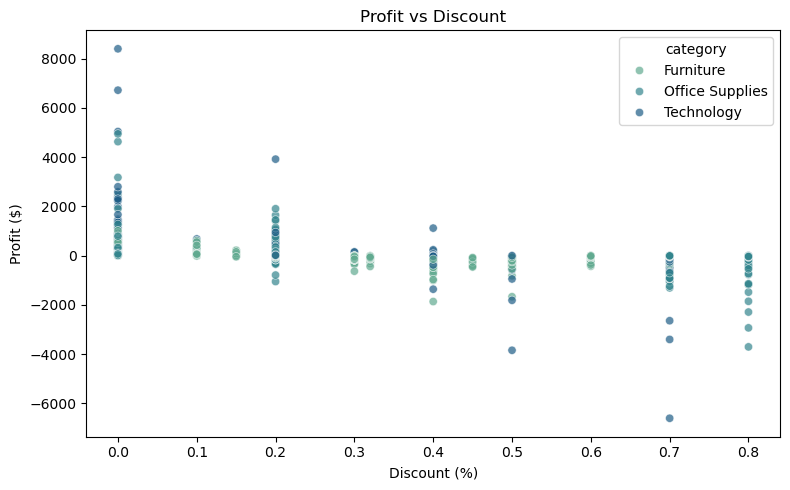

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="discount", y="profit",
    hue="category",
    palette="crest",
    alpha=0.7
)
plt.title("Profit vs Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.savefig("../plots/profit_vs_discount_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()


## Top 10 Cities by Sales

### Plotly version

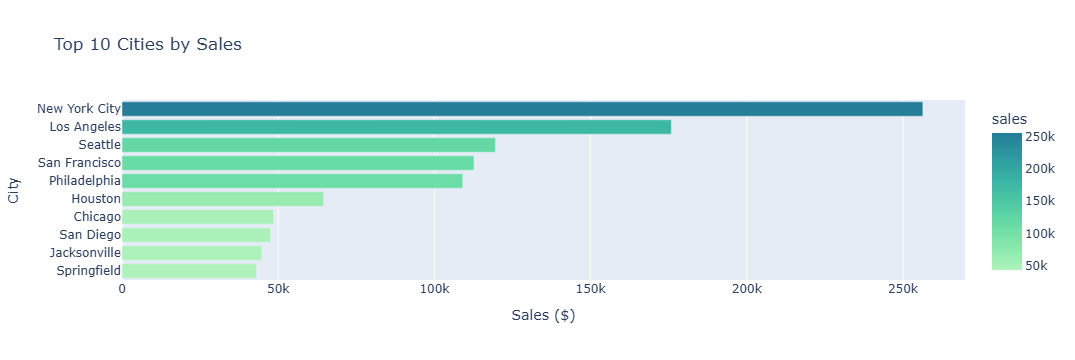

In [37]:
top_cities = df.groupby("city", as_index=False)["sales"].sum().nlargest(10, "sales")

fig = px.bar(
    top_cities, x="sales", y="city",
    orientation="h",
    title="Top 10 Cities by Sales",
    color="sales", color_continuous_scale="Tealgrn"
    
)
fig.update_layout(xaxis_title="Sales ($)", yaxis_title="City")
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.write_image("../plots/top_10_cities_by_sales_plotly.png", scale=3)
fig.show()


### Seaborn version

C:\Users\venzo\AppData\Local\Temp\ipykernel_14020\4040982041.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




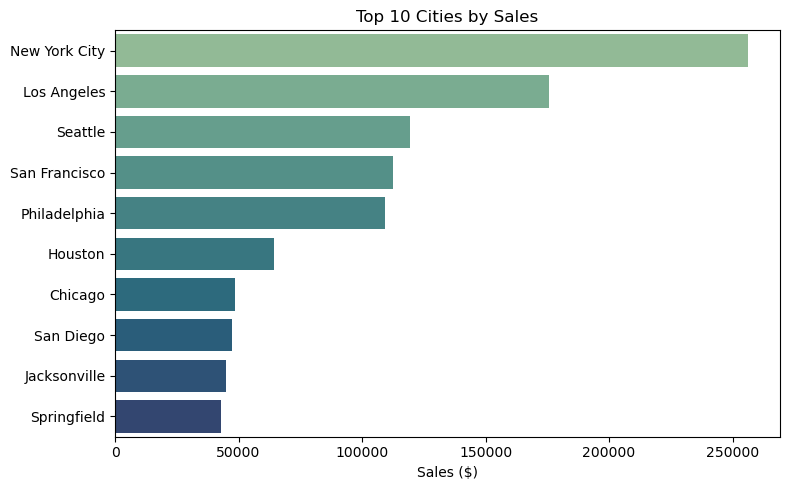

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(data=top_cities, x="sales", y="city", palette="crest")
plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../plots/top_10_cities_by_sales_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()


# Key Findings

1️⃣ Overall Performance

Total sales reached $2.3 M, generating $286 K profit with a 12.5 % margin.

An average discount of 15.6 % suggests opportunities to improve pricing strategy.

2️⃣ Category Insights

Technology achieved the highest revenue ($836 K) and strongest profit margin (17.4 %).

Office Supplies also performed well (17 % margin).

Furniture underperformed, producing only 2.5 % margin — possibly due to high shipping costs or heavy discounts.

3️⃣ Customer Segments

The Consumer segment brought the highest sales (≈ $1.16 M) but moderate profitability (11.5 %).

Home Office showed smaller revenue but stronger margins (~14 %), indicating loyal, high-value clients.

4️⃣ Regional Insights

West region leads in both revenue and profitability (≈ 15 % margin).

Central region struggles, with the lowest margin (7.9 %) — possibly an efficiency or logistics issue.

5️⃣ Discount vs Profit Relationship

Scatter analysis confirms a negative correlation: high discounts sharply reduce profit.
Pricing policies could be optimized for sustainable margins.

# Business Recommendations

Re-evaluate discount strategy, particularly in Furniture.

Prioritize Technology and Office Supplies categories for marketing investment.

Investigate Central region supply chain or pricing inefficiencies.

Target Home Office customers with loyalty programs — they deliver stable profit.